# Segmentación interactiva de tumores con GrabCut

Este cuaderno ilustra GrabCut como una secuencia de operaciones: **selección de ROI → inicialización → apariencia → vecindad → optimización → máscara binaria → validación**.

El objetivo no es reimplementar un solver de *min-cut/max-flow* desde cero, sino separar con claridad las piezas matemáticas que intervienen y utilizar `cv2.grabCut` únicamente como backend robusto para la etapa de optimización del grafo.

## Archivos esperados

El cuaderno asume esta estructura relativa:

```text
grabcut.ipynb
imagenes/
    rm_cerebral.jpeg
    rm_cerebral_ground_truth.jpeg
```

Convención del proyecto:

- `rm_cerebral.jpeg`: imagen sobre la cual se ejecuta GrabCut; se procesa como escala de grises.
- `rm_cerebral_ground_truth.jpeg`: misma imagen/corte con el tumor resaltado en rojo.

> Para seleccionar la ROI de forma interactiva se recomienda `ipympl`: `pip install ipympl`.

In [21]:
# 1. Importaciones y backend interactivo
from pathlib import Path
import os

import cv2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import RectangleSelector

# Intentamos activar el backend interactivo de Matplotlib para Jupyter.
# Si ipympl no está instalado, el notebook sigue funcionando y se puede usar la ROI manual.
try:
    get_ipython().run_line_magic("matplotlib", "widget")
    BACKEND_INTERACTIVO = True
except Exception as exc:
    BACKEND_INTERACTIVO = False
    print("No se pudo activar '%matplotlib widget'.")
    print("Instale ipympl con: pip install ipympl")
    print("Puede continuar usando rect_roi_manual más adelante.")

## 2. Carga robusta de imágenes

La lectura usa `cv2.imread` y, como respaldo, `cv2.imdecode(np.fromfile(...))`. Esto permite trabajar con rutas que contienen espacios, tildes u otros caracteres especiales.

La comparación con el *ground truth* solo es válida si ambas imágenes corresponden al mismo corte y conservan exactamente las mismas dimensiones espaciales; por eso **no se redimensiona automáticamente** ninguna imagen.

In [22]:
def leer_imagen(ruta, flags=cv2.IMREAD_GRAYSCALE):
    """Lee una imagen de forma robusta, incluso con caracteres especiales en la ruta."""
    ruta = Path(ruta)

    if not ruta.exists():
        raise FileNotFoundError(f"No se encontró el archivo: {ruta}")

    img = cv2.imread(str(ruta), flags)

    if img is None:
        buffer = np.fromfile(str(ruta), dtype=np.uint8)
        img = cv2.imdecode(buffer, flags)

    if img is None:
        raise ValueError(f"OpenCV no pudo decodificar la imagen: {ruta}")

    return img


def validar_imagenes(imagen_gris, ground_truth_bgr):
    """Verifica dimensiones, tipo de dato y alineamiento espacial básico."""
    if imagen_gris.ndim != 2:
        raise ValueError("La imagen de trabajo debe ser bidimensional (escala de grises).")

    if ground_truth_bgr.ndim != 3 or ground_truth_bgr.shape[2] != 3:
        raise ValueError("El ground truth debe cargarse en color (BGR).")

    if imagen_gris.shape != ground_truth_bgr.shape[:2]:
        raise ValueError(
            "Dimensiones incompatibles: "
            f"imagen={imagen_gris.shape}, ground_truth={ground_truth_bgr.shape[:2]}. "
            "No se realizará resize automático."
        )

    if imagen_gris.dtype != np.uint8:
        raise TypeError(f"Se esperaba uint8 para la imagen de trabajo; se obtuvo {imagen_gris.dtype}.")

    if ground_truth_bgr.dtype != np.uint8:
        raise TypeError(f"Se esperaba uint8 para el ground truth; se obtuvo {ground_truth_bgr.dtype}.")


RUTA_IMAGEN = Path("imagenes/rm_cerebral.jpeg")
RUTA_GROUND_TRUTH = Path("imagenes/rm_cerebral_ground_truth.jpeg")

imagen_gris = leer_imagen(RUTA_IMAGEN, cv2.IMREAD_GRAYSCALE)
imagen_ground_truth_bgr = leer_imagen(RUTA_GROUND_TRUTH, cv2.IMREAD_COLOR)
validar_imagenes(imagen_gris, imagen_ground_truth_bgr)

print(f"Imagen de trabajo: {imagen_gris.shape}, {imagen_gris.dtype}")
print(f"Ground truth:      {imagen_ground_truth_bgr.shape}, {imagen_ground_truth_bgr.dtype}")

Imagen de trabajo: (512, 512), uint8
Ground truth:      (512, 512, 3), uint8


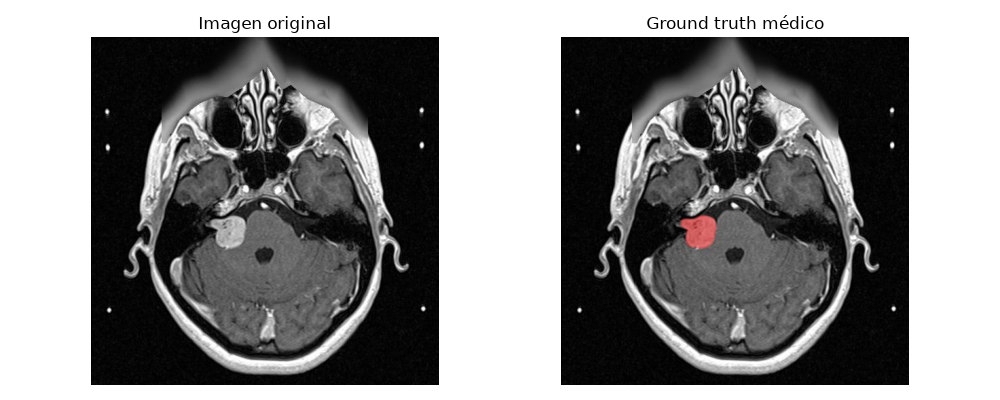

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(imagen_gris, cmap="gray")
axes[0].set_title("Imagen original")
axes[0].axis("off")

axes[1].imshow(cv2.cvtColor(imagen_ground_truth_bgr, cv2.COLOR_BGR2RGB))
axes[1].set_title("Ground truth médico")
axes[1].axis("off")

plt.tight_layout()
plt.show()

## 3. Adaptación de la imagen gris para OpenCV GrabCut

La imagen científica original se conserva como `imagen_gris`. OpenCV GrabCut espera una imagen de 8 bits y tres canales, por lo que se crea una copia BGR únicamente para satisfacer esa interfaz:

\[
I_{BGR}(x,y) = [I(x,y), I(x,y), I(x,y)].
\]

Esta conversión **no añade información cromática**; solo replica la misma intensidad en los tres canales.

In [24]:
def gris_a_bgr_para_grabcut(imagen_gris):
    """Replica la intensidad gris en tres canales para la interfaz de cv2.grabCut."""
    if imagen_gris.ndim != 2 or imagen_gris.dtype != np.uint8:
        raise ValueError("Se requiere una imagen gris uint8.")
    return cv2.cvtColor(imagen_gris, cv2.COLOR_GRAY2BGR)


imagen_bgr = gris_a_bgr_para_grabcut(imagen_gris)

## 4. Selección interactiva de la ROI

La ROI rectangular no es la segmentación final. Solo indica a GrabCut una región que contiene el tumor y un margen de tejido circundante.

Se almacena como

\[
\mathrm{ROI}=(x,y,w,h),
\]

donde \((x,y)\) es la esquina superior izquierda y \(w,h\) son ancho y alto en píxeles.

**Instrucción:** ejecute la celda siguiente, dibuje un rectángulo alrededor del tumor y reajústelo si lo necesita. Después ejecute la celda de confirmación.

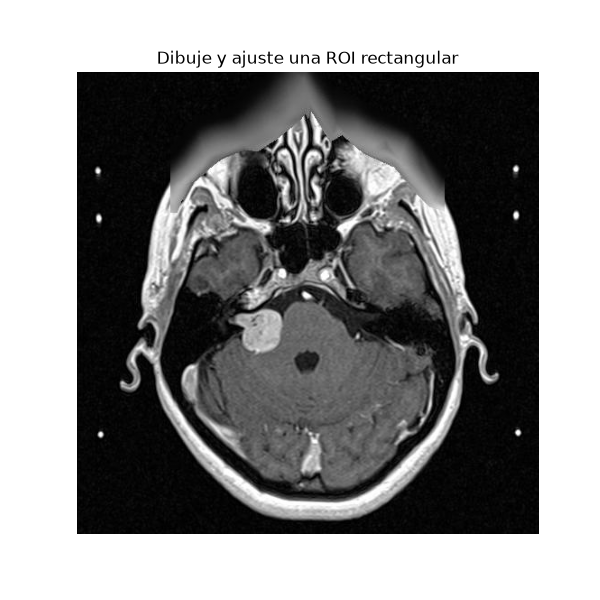

In [ ]:
class SelectorROI:
    """Selector interactivo de una ROI rectangular."""

    def __init__(self, imagen):
        self.imagen = imagen

        self.fig = None
        self.ax = None
        self.selector = None

        self.rect_roi = None
        self.seleccion_realizada = False

    def _al_seleccionar(self, eclick, erelease):
        """
        Callback ejecutado al terminar de dibujar
        el rectángulo.
        """

        if (
            eclick.xdata is None
            or eclick.ydata is None
            or erelease.xdata is None
            or erelease.ydata is None
        ):
            return

        # Coordenadas inicial y final del arrastre
        x1 = float(eclick.xdata)
        y1 = float(eclick.ydata)

        x2 = float(erelease.xdata)
        y2 = float(erelease.ydata)

        # Ordenar las esquinas
        x_min = int(np.floor(min(x1, x2)))
        x_max = int(np.ceil(max(x1, x2)))

        y_min = int(np.floor(min(y1, y2)))
        y_max = int(np.ceil(max(y1, y2)))

        alto, ancho = self.imagen.shape[:2]

        # Limitar a las dimensiones de la imagen
        x_min = int(np.clip(x_min, 0, ancho - 1))
        x_max = int(np.clip(x_max, 1, ancho))

        y_min = int(np.clip(y_min, 0, alto - 1))
        y_max = int(np.clip(y_max, 1, alto))

        w = x_max - x_min
        h = y_max - y_min

        # Evitar selecciones accidentales
        if w < 5 or h < 5:
            print(
                "ROI demasiado pequeña. "
                "Dibuje nuevamente el rectángulo."
            )

            self.rect_roi = None
            self.seleccion_realizada = False
            return

        self.rect_roi = (
            x_min,
            y_min,
            w,
            h,
        )

        self.seleccion_realizada = True

        print(
            "ROI seleccionada correctamente:"
        )
        print(f"x     = {x_min}")
        print(f"y     = {y_min}")
        print(f"ancho = {w}")
        print(f"alto  = {h}")

    def mostrar(self):
        """Muestra la imagen y habilita la selección."""

        self.fig, self.ax = plt.subplots(
            figsize=(7, 7)
        )

        self.ax.imshow(
            self.imagen,
            cmap="gray"
        )

        self.ax.set_title(
            "Clic izquierdo + arrastrar para seleccionar la ROI"
        )

        self.ax.axis("off")

        self.selector = RectangleSelector(
            self.ax,
            self._al_seleccionar,

            # Botón izquierdo
            button=[1],

            # Más robusto con ipympl / VS Code
            useblit=False,

            # Permite reajustar después
            interactive=True,

            # Evita selecciones diminutas
            minspanx=5,
            minspany=5,

            spancoords="pixels",
        )

        plt.show()

        return self

    def obtener_rectangulo(self):
        """Devuelve la última ROI válida seleccionada."""

        if not self.seleccion_realizada:
            raise RuntimeError(
                "Todavía no se ha seleccionado una ROI válida. "
                "Dibuje primero un rectángulo sobre la imagen."
            )

        return self.rect_roi


selector_roi = SelectorROI(imagen_gris).mostrar()

In [ ]:
def validar_rect_roi(rect_roi, shape):
    """Valida que (x, y, w, h) esté dentro de la imagen."""
    if rect_roi is None or len(rect_roi) != 4:
        raise ValueError("La ROI debe tener la forma (x, y, w, h).")

    x, y, w, h = map(int, rect_roi)
    alto, ancho = shape[:2]

    if w <= 0 or h <= 0:
        raise ValueError("La ROI debe tener ancho y alto positivos.")

    if x < 0 or y < 0 or x + w > ancho or y + h > alto:
        raise ValueError(f"ROI fuera de límites para una imagen de tamaño {ancho}x{alto}.")

    return (x, y, w, h)


# Alternativa manual si ipympl no está disponible.
# Ejemplo: rect_roi_manual = (150, 240, 100, 100)
rect_roi_manual = None

if rect_roi_manual is not None:
    rect_roi = validar_rect_roi(rect_roi_manual, imagen_gris.shape)
else:
    if not BACKEND_INTERACTIVO:
        raise RuntimeError(
            "No hay backend interactivo. Defina rect_roi_manual = (x, y, w, h) y vuelva a ejecutar esta celda."
        )
    rect_roi = validar_rect_roi(selector_roi.obtener_rectangulo(), imagen_gris.shape)

x, y, w, h = rect_roi
print("ROI confirmada:")
print(f"x = {x}")
print(f"y = {y}")
print(f"ancho = {w}")
print(f"alto = {h}")

ROI confirmada:
x = 0
y = 0
ancho = 1
alto = 1


## 5. Inicialización de etiquetas

OpenCV usa cuatro etiquetas:

- `GC_BGD = 0`: fondo seguro.
- `GC_FGD = 1`: *foreground* seguro.
- `GC_PR_BGD = 2`: fondo probable.
- `GC_PR_FGD = 3`: *foreground* probable.

Con una inicialización puramente rectangular, los píxeles fuera de la ROI se consideran fondo seguro y los píxeles dentro de ella *foreground* probable.

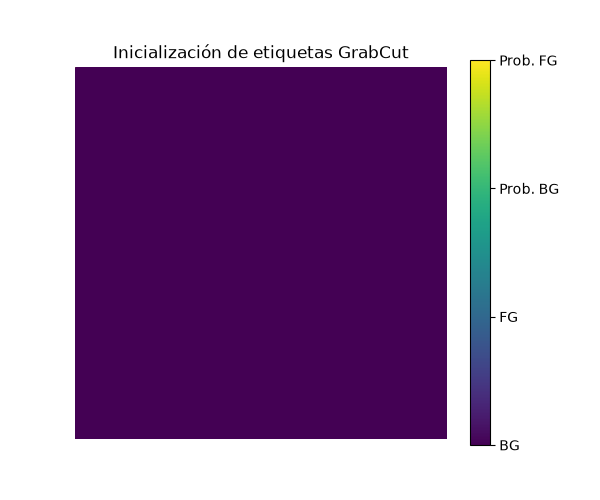

In [27]:
def inicializar_mascara_grabcut(shape, rect_roi):
    """Construye la máscara inicial: fondo seguro fuera de la ROI y foreground probable dentro."""
    rect_roi = validar_rect_roi(rect_roi, shape)
    x, y, w, h = rect_roi

    mascara = np.full(shape[:2], cv2.GC_BGD, dtype=np.uint8)
    mascara[y:y+h, x:x+w] = cv2.GC_PR_FGD
    return mascara


mascara_inicial = inicializar_mascara_grabcut(imagen_gris.shape, rect_roi)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(mascara_inicial, cmap="viridis", vmin=0, vmax=3)
ax.set_title("Inicialización de etiquetas GrabCut")
ax.axis("off")
cb = plt.colorbar(im, ax=ax, ticks=[0, 1, 2, 3])
cb.ax.set_yticklabels(["BG", "FG", "Prob. BG", "Prob. FG"])
plt.show()

## 6. Modelo de apariencia

GrabCut representa la distribución de intensidades de fondo y objeto mediante mezclas gaussianas. En esta versión pedagógica de una imagen gris:

\[
p(x_i\mid a_i=a)=\sum_{k=1}^{K} w_{a,k}\,\mathcal{N}(x_i;\mu_{a,k},\sigma_{a,k}^2).
\]

El costo unario de asignar un píxel a una clase se interpreta como

\[
D_i(a)=-\log\left(p(x_i\mid a)+\varepsilon\right).
\]

Así, una intensidad muy compatible con una clase produce un costo bajo.

> Las funciones siguientes son una representación matemática transparente del término de apariencia. La implementación interna exacta de OpenCV emplea sus propios GMM multicanal durante `cv2.grabCut`.

In [28]:
def _submuestrear_1d(valores, max_muestras=50000, semilla=0):
    valores = np.asarray(valores, dtype=np.float64).ravel()
    if valores.size == 0:
        raise ValueError("No hay muestras para ajustar el modelo de apariencia.")
    if valores.size <= max_muestras:
        return valores
    rng = np.random.default_rng(semilla)
    idx = rng.choice(valores.size, size=max_muestras, replace=False)
    return valores[idx]


def densidad_gaussiana_1d(x, media, varianza, eps=1e-8):
    varianza = max(float(varianza), eps)
    coef = 1.0 / np.sqrt(2.0 * np.pi * varianza)
    return coef * np.exp(-0.5 * ((x - media) ** 2) / varianza)


def ajustar_gmm_1d(valores, n_componentes=5, n_iteraciones=30, eps=1e-6):
    """Ajusta un GMM 1D sencillo mediante EM para fines pedagógicos."""
    x = _submuestrear_1d(valores)
    n = x.size
    k = int(min(max(1, n_componentes), n))

    cuantiles = np.linspace(0.05, 0.95, k)
    medias = np.quantile(x, cuantiles).astype(np.float64)
    var_global = max(float(np.var(x)), 25.0)
    varianzas = np.full(k, var_global, dtype=np.float64)
    pesos = np.full(k, 1.0 / k, dtype=np.float64)

    for _ in range(n_iteraciones):
        densidades = np.column_stack([
            densidad_gaussiana_1d(x, medias[j], varianzas[j], eps)
            for j in range(k)
        ])
        numerador = densidades * pesos
        denominador = np.sum(numerador, axis=1, keepdims=True) + eps
        responsabilidades = numerador / denominador

        Nk = np.sum(responsabilidades, axis=0) + eps
        pesos = Nk / np.sum(Nk)
        medias = np.sum(responsabilidades * x[:, None], axis=0) / Nk
        varianzas = (
            np.sum(responsabilidades * (x[:, None] - medias[None, :]) ** 2, axis=0) / Nk
        )
        varianzas = np.maximum(varianzas, 4.0)

    return {
        "pesos": pesos,
        "medias": medias,
        "varianzas": varianzas,
    }


def probabilidad_apariencia(intensidades, modelo, eps=1e-12):
    """Evalúa p(x|clase) para un GMM 1D."""
    x = np.asarray(intensidades, dtype=np.float64)
    p = np.zeros_like(x, dtype=np.float64)

    for peso, media, varianza in zip(
        modelo["pesos"], modelo["medias"], modelo["varianzas"]
    ):
        p += peso * densidad_gaussiana_1d(x, media, varianza)

    return np.maximum(p, eps)


def costo_apariencia(intensidades, modelo, eps=1e-12):
    """Calcula D=-log p(x|clase)."""
    return -np.log(probabilidad_apariencia(intensidades, modelo, eps))


def estimar_modelos_apariencia(
    imagen_gris,
    mascara,
    n_componentes=5,
):
    """
    Estima modelos GMM pedagógicos para fondo y foreground.

    Fondo:
        GC_BGD y GC_PR_BGD

    Foreground:
        GC_FGD y GC_PR_FGD
    """

    es_fondo = np.isin(
        mascara,
        [
            cv2.GC_BGD,
            cv2.GC_PR_BGD,
        ],
    )

    es_foreground = np.isin(
        mascara,
        [
            cv2.GC_FGD,
            cv2.GC_PR_FGD,
        ],
    )

    valores_bg = imagen_gris[es_fondo]
    valores_fg = imagen_gris[es_foreground]

    print(
        f"Muestras de fondo:     {valores_bg.size}"
    )
    print(
        f"Muestras de foreground: {valores_fg.size}"
    )

    if valores_bg.size < 10:
        raise ValueError(
            "No hay suficientes muestras de fondo "
            "para ajustar el GMM."
        )

    if valores_fg.size < 10:
        raise ValueError(
            "No hay suficientes muestras de foreground "
            "para ajustar el GMM. Revise la ROI."
        )

    modelo_bg = ajustar_gmm_1d(
        valores_bg,
        n_componentes=n_componentes,
    )

    modelo_fg = ajustar_gmm_1d(
        valores_fg,
        n_componentes=n_componentes,
    )

    return modelo_bg, modelo_fg


modelo_bg, modelo_fg = estimar_modelos_apariencia(imagen_gris, mascara_inicial)
costo_bg = costo_apariencia(imagen_gris, modelo_bg)
costo_fg = costo_apariencia(imagen_gris, modelo_fg)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].imshow(imagen_gris, cmap="gray")
axes[0].set_title("Intensidad")
axes[1].imshow(costo_bg, cmap="magma")
axes[1].set_title("Costo de apariencia: fondo")
axes[2].imshow(costo_fg, cmap="magma")
axes[2].set_title("Costo de apariencia: tumor")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

Muestras de fondo:     262143
Muestras de foreground: 1


ValueError: No hay suficientes muestras de foreground para ajustar el GMM. Revise la ROI.

## 7. Vecindad y término de suavidad

El término espacial penaliza separar píxeles vecinos que se parecen en intensidad. Una forma estándar es

\[
V_{ij}=\frac{\gamma}{d(i,j)}\exp\left[-\beta(I_i-I_j)^2\right].
\]

- \(\beta\) adapta la sensibilidad al contraste de la imagen.
- \(\gamma\) controla cuánto pesa la coherencia espacial.
- Si dos vecinos son muy parecidos, separarlos cuesta más.
- Si existe una discontinuidad fuerte de intensidad, colocar allí una frontera cuesta menos.

Se usa vecindad 8-conectada sin construir una matriz \(N\times N\).

In [ ]:
def obtener_vecinos_8(shape):
    """Devuelve pares de slices que representan una vecindad 8-conectada sin duplicar aristas."""
    h, w = shape[:2]
    if h < 2 or w < 2:
        raise ValueError("La imagen es demasiado pequeña para una vecindad 8-conectada.")

    return [
        ("derecha",  (slice(None), slice(0, -1)), (slice(None), slice(1, None)), 1.0),
        ("abajo",    (slice(0, -1), slice(None)), (slice(1, None), slice(None)), 1.0),
        ("diag_dr",  (slice(0, -1), slice(0, -1)), (slice(1, None), slice(1, None)), np.sqrt(2.0)),
        ("diag_dl",  (slice(0, -1), slice(1, None)), (slice(1, None), slice(0, -1)), np.sqrt(2.0)),
    ]


def calcular_beta(imagen_gris):
    """Calcula beta = 1/(2 E[(I_i-I_j)^2]) sobre vecinos 8-conectados."""
    imagen = imagen_gris.astype(np.float64)
    diferencias2 = []

    for _, s1, s2, _ in obtener_vecinos_8(imagen.shape):
        diferencias2.append((imagen[s1] - imagen[s2]) ** 2)

    promedio = np.mean(np.concatenate([d.ravel() for d in diferencias2]))
    if promedio <= np.finfo(np.float64).eps:
        return 0.0
    return 1.0 / (2.0 * promedio)


def calcular_pesos_vecindad(imagen_gris, beta=None, gamma=50.0):
    """Calcula los pesos V_ij para cada dirección de la vecindad."""
    imagen = imagen_gris.astype(np.float64)
    beta = calcular_beta(imagen_gris) if beta is None else float(beta)
    pesos = {}

    for nombre, s1, s2, distancia in obtener_vecinos_8(imagen.shape):
        diferencia2 = (imagen[s1] - imagen[s2]) ** 2
        pesos[nombre] = (gamma / distancia) * np.exp(-beta * diferencia2)

    return beta, pesos


def costo_separar_vecinos(etiquetas_binarias, pesos_vecindad):
    """Suma V_ij únicamente donde dos vecinos reciben etiquetas diferentes."""
    etiquetas = np.asarray(etiquetas_binarias, dtype=np.uint8)
    total = 0.0

    for nombre, s1, s2, _ in obtener_vecinos_8(etiquetas.shape):
        diferentes = etiquetas[s1] != etiquetas[s2]
        total += float(np.sum(pesos_vecindad[nombre][diferentes]))

    return total


beta, pesos_vecindad = calcular_pesos_vecindad(imagen_gris)
print(f"beta = {beta:.6e}")

## 8. Energía

La estructura conceptual es

\[
E(a)=U(a)+V(a),
\]

con:

- \(U\): costo de apariencia (*unary term*).
- \(V\): costo por separar vecinos (*pairwise/smoothness term*).

Las funciones siguientes permiten inspeccionar esa formulación con nuestros GMM pedagógicos. No deben interpretarse como una reproducción exacta de la energía interna privada de OpenCV.

In [ ]:
def energia_apariencia(etiquetas_binarias, costo_fondo, costo_foreground):
    """Suma el costo unario correspondiente a la etiqueta elegida en cada píxel."""
    etiquetas = np.asarray(etiquetas_binarias, dtype=np.uint8)
    if etiquetas.shape != costo_fondo.shape or etiquetas.shape != costo_foreground.shape:
        raise ValueError("Las etiquetas y los mapas de costo deben tener la misma forma.")

    return float(np.sum(np.where(etiquetas == 1, costo_foreground, costo_fondo)))


def energia_suavidad(etiquetas_binarias, pesos_vecindad):
    """Alias semántico del costo total por separar vecinos."""
    return costo_separar_vecinos(etiquetas_binarias, pesos_vecindad)


def energia_total(etiquetas_binarias, costo_fondo, costo_foreground, pesos_vecindad):
    """Devuelve E, U y V para facilitar inspección y diagnóstico."""
    U = energia_apariencia(etiquetas_binarias, costo_fondo, costo_foreground)
    V = energia_suavidad(etiquetas_binarias, pesos_vecindad)
    return U + V, U, V


etiquetas_iniciales_binarias = np.isin(
    mascara_inicial, [cv2.GC_FGD, cv2.GC_PR_FGD]
).astype(np.uint8)

E0, U0, V0 = energia_total(
    etiquetas_iniciales_binarias, costo_bg, costo_fg, pesos_vecindad
)

print(f"Energía diagnóstica inicial: E={E0:.3e}, U={U0:.3e}, V={V0:.3e}")

## 9. Optimización con Graph Cut

Con los modelos fijados, GrabCut busca una asignación binaria de etiquetas que minimice la energía. Conceptualmente:

\[
a^*=\operatorname*{arg\,min}_{a} E(a).
\]

La resolución eficiente del corte mínimo se delega a `cv2.grabCut`. De esta forma se mantiene visible la arquitectura matemática sin reimplementar un solver de flujo máximo.

La ejecución se hace **una iteración por vez** para conservar un historial de máscaras y mostrar la naturaleza iterativa del algoritmo.

In [ ]:
def optimizar_segmentacion(
    imagen_bgr,
    mascara,
    modelo_bg_opencv,
    modelo_fg_opencv,
    modo,
):
    """Ejecuta exactamente una iteración del optimizador GrabCut de OpenCV."""
    cv2.grabCut(
        imagen_bgr,
        mascara,
        None,
        modelo_bg_opencv,
        modelo_fg_opencv,
        1,
        modo,
    )
    return mascara


def ejecutar_grabcut(imagen_bgr, mascara_inicial, numero_iteraciones=5, semilla=2026):
    """Ejecuta GrabCut iterativamente y conserva la evolución de la máscara."""
    if numero_iteraciones < 1:
        raise ValueError("numero_iteraciones debe ser >= 1.")

    cv2.setRNGSeed(int(semilla))  # reproducibilidad de la inicialización interna de OpenCV
    mascara = mascara_inicial.copy()
    modelo_bg_opencv = np.zeros((1, 65), dtype=np.float64)
    modelo_fg_opencv = np.zeros((1, 65), dtype=np.float64)
    historial = [mascara.copy()]

    # Primera iteración: la máscara rectangular explícita inicializa el algoritmo.
    mascara = optimizar_segmentacion(
        imagen_bgr,
        mascara,
        modelo_bg_opencv,
        modelo_fg_opencv,
        cv2.GC_INIT_WITH_MASK,
    )
    historial.append(mascara.copy())

    # Iteraciones posteriores: se reutilizan GMM y etiquetas previas.
    for _ in range(1, numero_iteraciones):
        mascara = optimizar_segmentacion(
            imagen_bgr,
            mascara,
            modelo_bg_opencv,
            modelo_fg_opencv,
            cv2.GC_EVAL,
        )
        historial.append(mascara.copy())

    return mascara, historial, modelo_bg_opencv, modelo_fg_opencv


def convertir_mascara_grabcut_a_binaria(mascara_grabcut):
    """Convierte las etiquetas GrabCut a {0,1}: foreground seguro o probable -> 1."""
    return np.isin(
        mascara_grabcut,
        [cv2.GC_FGD, cv2.GC_PR_FGD],
    ).astype(np.uint8)


NUMERO_ITERACIONES = 5
mascara_grabcut, historial_mascaras, bgd_model, fgd_model = ejecutar_grabcut(
    imagen_bgr,
    mascara_inicial,
    numero_iteraciones=NUMERO_ITERACIONES,
)
mascara_binaria = convertir_mascara_grabcut_a_binaria(mascara_grabcut)

print(f"Píxeles clasificados como tumor: {int(mascara_binaria.sum())}")

In [ ]:
def visualizar_evolucion(historial):
    """Muestra un subconjunto representativo de la evolución de GrabCut."""
    n = len(historial)
    indices = sorted(set([0, 1, n // 2, n - 1]))

    fig, axes = plt.subplots(1, len(indices), figsize=(4 * len(indices), 4))
    if len(indices) == 1:
        axes = [axes]

    for ax, idx in zip(axes, indices):
        binaria = convertir_mascara_grabcut_a_binaria(historial[idx])
        ax.imshow(binaria, cmap="gray", vmin=0, vmax=1)
        titulo = "Inicial" if idx == 0 else f"Iteración {idx}"
        ax.set_title(titulo)
        ax.axis("off")

    plt.tight_layout()
    plt.show()


visualizar_evolucion(historial_mascaras)

## 10. Extracción del *ground truth* rojo

La imagen anotada no se compara directamente con la máscara binaria de GrabCut. Primero se extrae la región roja.

Como las imágenes JPEG pueden introducir pequeñas variaciones de color, no se usa una igualdad exacta del tipo `pixel == [255,0,0]`. Se combinan:

1. detección del rojo en HSV, incluyendo ambos extremos del eje circular de *Hue*;
2. predominio del canal rojo respecto de verde y azul.

No se aplican operaciones morfológicas por defecto, para no alterar silenciosamente la anotación médica.

In [ ]:
def extraer_ground_truth_rojo(
    imagen_bgr,
    saturacion_min=60,
    valor_min=50,
    margen_rojo=30,
    rojo_min=90,
):
    """Extrae una máscara binaria robusta de la anotación roja en una imagen BGR/JPEG."""
    if imagen_bgr.ndim != 3 or imagen_bgr.shape[2] != 3:
        raise ValueError("Se requiere una imagen BGR de tres canales.")

    hsv = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2HSV)
    h, s, v = cv2.split(hsv)

    rojo_hsv = (
        ((h <= 12) | (h >= 168))
        & (s >= saturacion_min)
        & (v >= valor_min)
    )

    b, g, r = cv2.split(imagen_bgr)
    r16 = r.astype(np.int16)
    g16 = g.astype(np.int16)
    b16 = b.astype(np.int16)

    rojo_dominante = (
        (r >= rojo_min)
        & ((r16 - g16) >= margen_rojo)
        & ((r16 - b16) >= margen_rojo)
    )

    mascara = (rojo_hsv | rojo_dominante).astype(np.uint8)

    if mascara.sum() == 0:
        raise ValueError(
            "No se detectó ninguna región roja. Revise el archivo o ajuste los umbrales."
        )

    return mascara


ground_truth_binario = extraer_ground_truth_rojo(imagen_ground_truth_bgr)

fig, ax = plt.subplots(figsize=(6, 5))
ax.imshow(ground_truth_binario, cmap="gray", vmin=0, vmax=1)
ax.set_title("Máscara binaria extraída del ground truth rojo")
ax.axis("off")
plt.show()

print(f"Píxeles de ground truth: {int(ground_truth_binario.sum())}")

## 11. Validación cuantitativa

Antes de calcular métricas se exige alineamiento dimensional exacto.

Para máscaras binarias \(M,G\in\{0,1\}\), el error cuadrático medio es

\[
\mathrm{MSE}=\frac{1}{N}\sum_{i=1}^{N}(M_i-G_i)^2.
\]

Como \((M_i-G_i)^2\) vale 1 solo cuando las etiquetas difieren, el MSE equivale a la **fracción de píxeles mal clasificados**.

Se añaden Dice e IoU porque el fondo suele dominar la imagen completa y puede hacer que un MSE pequeño parezca mejor de lo que realmente es para la lesión.

In [ ]:
def validar_alineamiento(prediccion, ground_truth):
    """Exige igualdad espacial exacta entre predicción y referencia."""
    if prediccion.shape != ground_truth.shape:
        raise ValueError(
            f"Las máscaras no están alineadas: {prediccion.shape} != {ground_truth.shape}."
        )


def calcular_mse(prediccion, ground_truth):
    validar_alineamiento(prediccion, ground_truth)
    p = prediccion.astype(np.float64)
    g = ground_truth.astype(np.float64)
    return float(np.mean((p - g) ** 2))


def calcular_dice(prediccion, ground_truth, eps=1e-12):
    validar_alineamiento(prediccion, ground_truth)
    p = prediccion.astype(bool)
    g = ground_truth.astype(bool)
    interseccion = np.logical_and(p, g).sum()
    return float((2.0 * interseccion + eps) / (p.sum() + g.sum() + eps))


def calcular_iou(prediccion, ground_truth, eps=1e-12):
    validar_alineamiento(prediccion, ground_truth)
    p = prediccion.astype(bool)
    g = ground_truth.astype(bool)
    interseccion = np.logical_and(p, g).sum()
    union = np.logical_or(p, g).sum()
    return float((interseccion + eps) / (union + eps))


mse = calcular_mse(mascara_binaria, ground_truth_binario)
dice = calcular_dice(mascara_binaria, ground_truth_binario)
iou = calcular_iou(mascara_binaria, ground_truth_binario)

print(f"MSE GrabCut vs Ground Truth = {mse:.6f}")
print(f"Dice                         = {dice:.6f}")
print(f"IoU / Jaccard                = {iou:.6f}")

## 12. Visualización final

La comparación final conserva exactamente el formato solicitado: imagen original, resultado de GrabCut y *ground truth* médico en una sola fila.

In [ ]:
segmentacion_visual = imagen_gris * mascara_binaria

ground_truth_rgb = cv2.cvtColor(imagen_ground_truth_bgr, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(imagen_gris, cmap="gray")
axes[0].set_title("Imagen original")

axes[1].imshow(segmentacion_visual, cmap="gray")
axes[1].set_title("Resultado GrabCut")

axes[2].imshow(ground_truth_rgb)
axes[2].set_title("Ground truth médico")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

## 13. Lectura del pipeline completo

El cuaderno separó GrabCut en responsabilidades explícitas:

1. **Entrada:** lectura y validación de la RM y la anotación.
2. **Interacción:** selección rectangular de la ROI.
3. **Inicialización:** etiquetas de fondo seguro y *foreground* probable.
4. **Apariencia:** GMM y costo \(-\log p(x\mid a)\).
5. **Vecindad:** pesos dependientes del contraste y penalización por separar vecinos.
6. **Energía:** \(E=U+V\).
7. **Optimización:** corte de grafo delegado a `cv2.grabCut`.
8. **Iteración:** actualización repetida de modelos y etiquetas.
9. **Salida:** máscara binaria del tumor.
10. **Validación:** MSE obligatorio, complementado con Dice e IoU.

La ROI controla la inicialización, pero **no** define el contorno final de la lesión.